# 🌸 Coelogyne Orchid Classification
**Dataset:** 5 Spesies — Asperata, Dayana, Pandurata, Rumphii, Swaniana  
**Model 1:** MobileNetV2 (Transfer Learning, TensorFlow/Keras)  
**Model 2:** CSPDarknet53 (YOLO Backbone, Pure Keras)  

---

## 0. Install Dependencies

In [ ]:
# Uncomment jika belum install
# !pip install tensorflow matplotlib seaborn scikit-learn numpy pillow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 8.7 MB/s  0:00:25m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 15.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 15.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip uninstall -y tensorflow tensorflow-metal keras
!pip install "tensorflow==2.18.*" "tensorflow-metal==1.2.0"

Found existing installation: tensorflow 2.21.0
Uninstalling tensorflow-2.21.0:
  Successfully uninstalled tensorflow-2.21.0
Found existing installation: tensorflow-metal 1.2.0
Uninstalling tensorflow-metal-1.2.0:
  Successfully uninstalled tensorflow-metal-1.2.0
Found existing installation: keras 3.14.0
Uninstalling keras-3.14.0:
  Successfully uninstalled keras-3.14.0
  Using cached tensorflow_metal-1.2.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (1.3 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
Using cached tensorflow_metal-1.2.0-cp311-cp311-macosx_12_0_arm64.whl (1.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.5/239.5 MB 3.4 MB/s  0:00:54m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 15.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 15.9 MB/s  0:00:00 eta 0:00:01
Using cached keras-3.14.0-py3-none-any.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 9.9 MB/s  0:00:00m eta 0:00

## 1. Imports & Configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
import platform

# Apple Silicon GPU (Metal) support check
if platform.system() == "Darwin" and platform.machine() == "arm64":
    metal_gpus = tf.config.list_physical_devices("GPU")
    if not metal_gpus:
        print("⚠️ Apple Silicon terdeteksi, tapi GPU Metal belum aktif.")
        print("   Install: pip install tensorflow-metal")
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model

from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU Available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs               : {[g.name for g in gpus]}")

TensorFlow version : 2.18.1
Keras version      : 3.14.0
GPU Available      : True
GPUs               : ['/physical_device:GPU:0']


In [3]:
# ============================================================
#  CONFIGURATION — Sesuaikan path di sini
# ============================================================

# Root dataset (berisi folder: Asperata, Dayana, Pandurata, Rumphii, Swaniana)
DATASET_DIR = './data'   # <-- ganti sesuai lokasi lokal kamu

# Jika dataset BELUM di-split train/val, gunakan flow_from_directory dengan validation_split
# Jika sudah ada subfolder train/ & val/, set USE_SPLIT_DIR = True
USE_SPLIT_DIR = False
TRAIN_DIR     = os.path.join(DATASET_DIR, 'train')  # hanya dipakai jika USE_SPLIT_DIR=True
VAL_DIR       = os.path.join(DATASET_DIR, 'val')

# Hyperparameters
IMG_SIZE       = (224, 224)   # MobileNetV2 & CSPDarknet input
BATCH_SIZE     = 8
EPOCHS_HEAD    = 15           # Training hanya head (frozen backbone)
EPOCHS_FINETUNE= 20           # Fine-tuning seluruh model
LEARNING_RATE  = 1e-3
FINETUNE_LR    = 1e-5
VAL_SPLIT      = 0.2          # 80/20 train-val split
SEED           = 42

CLASS_NAMES = ['Asperata', 'Dayana', 'Pandurata', 'Rumphii', 'Swaniana']
NUM_CLASSES = len(CLASS_NAMES)

SAVE_DIR = './saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Dataset directory  : {DATASET_DIR}")
print(f"Image size         : {IMG_SIZE}")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Classes ({NUM_CLASSES})       : {CLASS_NAMES}")

Dataset directory  : ./data
Image size         : (224, 224)
Batch size         : 8
Classes (5)       : ['Asperata', 'Dayana', 'Pandurata', 'Rumphii', 'Swaniana']


## 2. Data Pipeline

In [4]:
# ----------------------------------------------------------------
#  Augmentation — ImageDataGenerator
# ----------------------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    validation_split  = VAL_SPLIT if not USE_SPLIT_DIR else 0.0,
    # Augmentasi
    rotation_range    = 30,
    width_shift_range = 0.15,
    height_shift_range= 0.15,
    shear_range       = 0.1,
    zoom_range        = 0.2,
    horizontal_flip   = True,
    vertical_flip     = False,
    brightness_range  = [0.8, 1.2],
    fill_mode         = 'nearest'
)

val_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = VAL_SPLIT if not USE_SPLIT_DIR else 0.0
)

# ----------------------------------------------------------------
#  Generators
# ----------------------------------------------------------------
if USE_SPLIT_DIR:
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=True, seed=SEED
    )
    val_gen = val_datagen.flow_from_directory(
        VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False, seed=SEED
    )
else:
    train_gen = train_datagen.flow_from_directory(
        DATASET_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='training',
        shuffle=True, seed=SEED
    )
    val_gen = val_datagen.flow_from_directory(
        DATASET_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='validation',
        shuffle=False, seed=SEED
    )

print(f"\nTrain samples : {train_gen.samples}")
print(f"Val samples   : {val_gen.samples}")
print(f"Class indices : {train_gen.class_indices}")

Found 317 images belonging to 5 classes.
Found 76 images belonging to 5 classes.

Train samples : 317
Val samples   : 76
Class indices : {'Asperata': 0, 'Dayana': 1, 'Pandurata': 2, 'Rumphii': 3, 'Swaniana': 4}


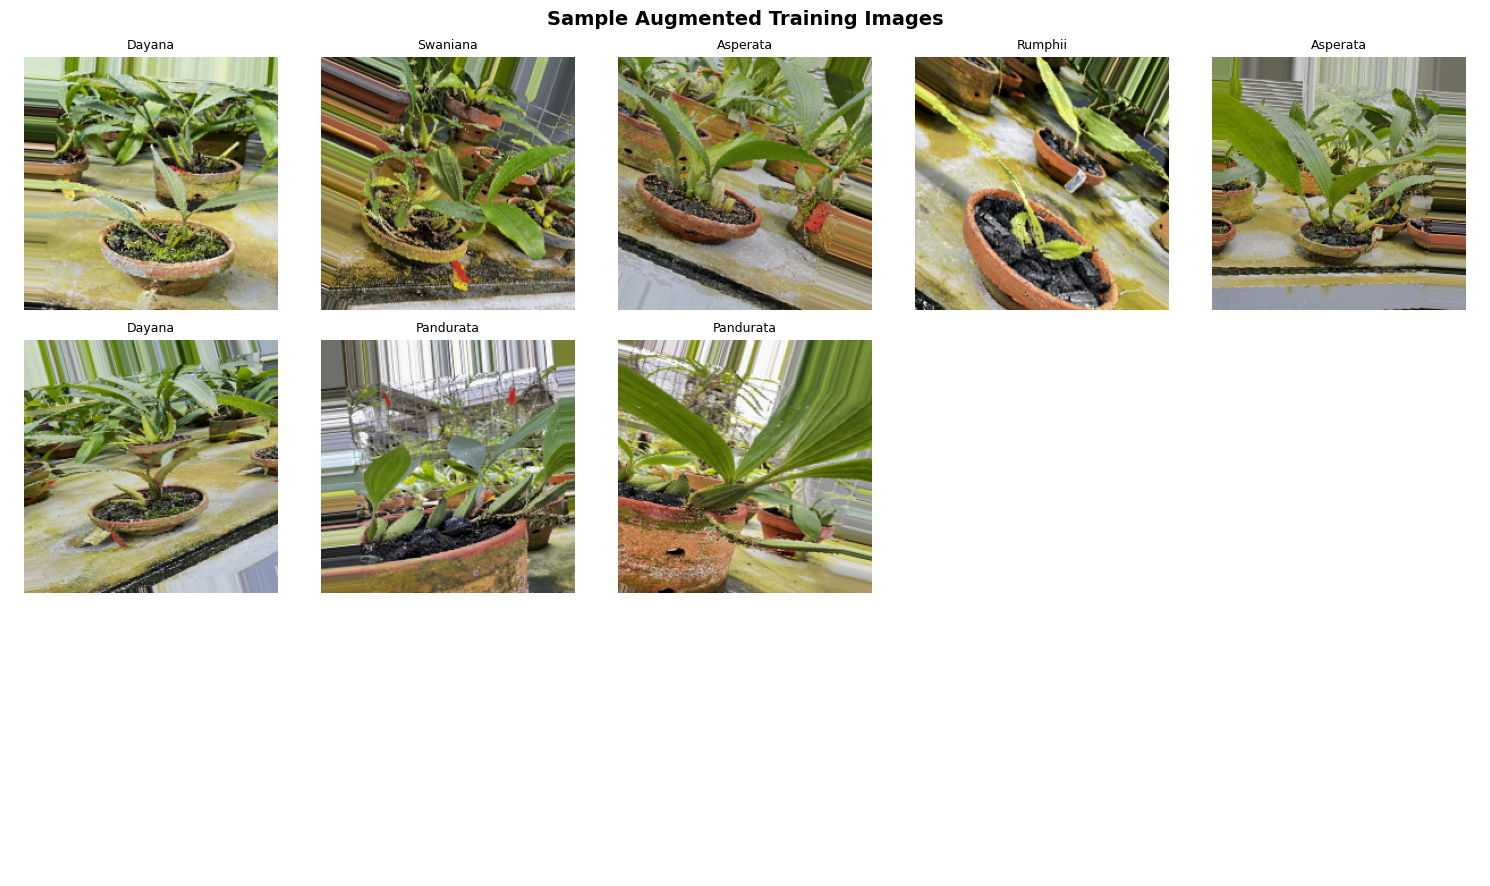

In [5]:
# ----------------------------------------------------------------
#  Visualisasi sampel per kelas
# ----------------------------------------------------------------
def show_sample_grid(generator, class_names, n_cols=5, n_rows=3, title=''):
    images, labels = next(generator)
    idx_to_class = {v: k for k, v in generator.class_indices.items()}
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i])
            label_idx = np.argmax(labels[i])
            ax.set_title(idx_to_class[label_idx], fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_grid(train_gen, CLASS_NAMES, title='Sample Augmented Training Images')
# Reset generator agar tidak kehilangan data
train_gen.reset()

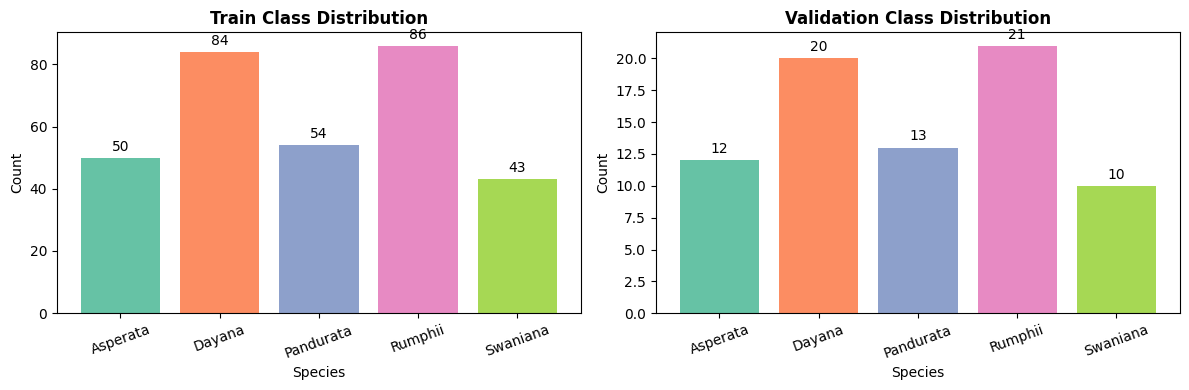

In [6]:
# ----------------------------------------------------------------
#  Distribusi kelas
# ----------------------------------------------------------------
import collections

train_counts = collections.Counter(train_gen.classes)
val_counts   = collections.Counter(val_gen.classes)
idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, split in zip(axes, [train_counts, val_counts], ['Train', 'Validation']):
    names  = [idx_to_class[i] for i in sorted(counts)]
    values = [counts[i]        for i in sorted(counts)]
    bars = ax.bar(names, values, color=plt.cm.Set2.colors[:len(names)])
    ax.bar_label(bars, fmt='%d', padding=3)
    ax.set_title(f'{split} Class Distribution', fontweight='bold')
    ax.set_xlabel('Species')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 3. Model 1 — MobileNetV2 (Transfer Learning)

In [7]:
# ----------------------------------------------------------------
#  Build MobileNetV2
# ----------------------------------------------------------------
def build_mobilenetv2(num_classes, img_size=IMG_SIZE, dropout=0.4):
    """
    MobileNetV2 pretrained ImageNet.
    Phase 1: Frozen backbone, hanya training classification head.
    Phase 2: Unfreeze top layers untuk fine-tuning.
    """
    inputs  = keras.Input(shape=(*img_size, 3), name='input_image')

    # Backbone — frozen di phase 1
    backbone = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = False

    x = backbone(inputs, training=False)

    # Head
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout, name='dropout_head')(x)
    x = layers.Dense(256, activation='relu', name='dense_256',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout * 0.5, name='dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_Coelogyne')
    return model, backbone

mobilenet_model, mobilenet_backbone = build_mobilenetv2(NUM_CLASSES)
mobilenet_model.summary(line_length=80)

2026-05-05 17:56:38.417948: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-05-05 17:56:38.418133: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-05-05 17:56:38.418148: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
I0000 00:00:1777978598.418654  846522 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1777978598.418844  846522 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "MobileNetV2_Coelogyne"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224 (Functional) │ (None, 7, 7, 1280)       │     2,257,984 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)      │ (None, 1280)             │         5,120 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_head (Dropout)            │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_256 (Dense)                 │ (None, 256)              │       327,936 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_2 (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ predictions (Dense)               │ (None, 5)                │         1,285 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 2,592,325 (9.89 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [8]:
# ----------------------------------------------------------------
#  Callbacks helper
# ----------------------------------------------------------------
def get_callbacks(model_name, monitor='val_accuracy'):
    return [
        callbacks.ModelCheckpoint(
            filepath=os.path.join(SAVE_DIR, f'{model_name}_best.keras'),
            monitor=monitor, save_best_only=True, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor=monitor, patience=8, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=4,
            min_lr=1e-7, verbose=1
        ),
        callbacks.TensorBoard(
            log_dir=f'./logs/{model_name}', histogram_freq=0
        )
    ]

In [9]:
# ================================================================
#  Phase 1: Training Head Only
# ================================================================
mobilenet_model.compile(
    optimizer=optimizers.Adam(LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable params (head only): {mobilenet_model.count_params():,}")

history_mn_head = mobilenet_model.fit(
    train_gen,
    epochs=EPOCHS_HEAD,
    validation_data=val_gen,
    callbacks=get_callbacks('mobilenetv2_head'),
    verbose=1
)
train_gen.reset(); val_gen.reset()

Trainable params (head only): 2,592,325
Epoch 1/15


2026-05-05 17:56:41.627902: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.3215 - loss: 2.7829
Epoch 1: val_accuracy improved from None to 0.40789, saving model to ./saved_models/mobilenetv2_head_best.keras

Epoch 1: finished saving model to ./saved_models/mobilenetv2_head_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 382ms/step - accuracy: 0.4669 - loss: 2.2790 - val_accuracy: 0.4079 - val_loss: 1.7920 - learning_rate: 0.0010
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.6745 - loss: 1.3322
Epoch 2: val_accuracy improved from 0.40789 to 0.44737, saving model to ./saved_models/mobilenetv2_head_best.keras

Epoch 2: finished saving model to ./saved_models/mobilenetv2_head_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 337ms/step - accuracy: 0.6782 - loss: 1.5010 - val_accuracy: 0.4474 - val_loss: 1.6234 - learning_rate: 0.0010
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.7306 - loss: 1.0491
Epoch 3: val_accuracy improved from 0.44737 to 0.53947, saving model to ./saved_models

In [10]:
# ================================================================
#  Phase 2: Fine-tuning — Unfreeze top 50 layers backbone
# ================================================================
mobilenet_backbone.trainable = True

# Freeze semua layer kecuali 50 terakhir
FINE_TUNE_FROM = len(mobilenet_backbone.layers) - 50
for layer in mobilenet_backbone.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for l in mobilenet_backbone.layers if l.trainable)
print(f"Total backbone layers      : {len(mobilenet_backbone.layers)}")
print(f"Fine-tuning from layer     : {FINE_TUNE_FROM}")
print(f"Trainable backbone layers  : {trainable_count}")

mobilenet_model.compile(
    optimizer=optimizers.Adam(FINETUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mn_ft = mobilenet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=get_callbacks('mobilenetv2_finetune'),
    verbose=1
)
train_gen.reset(); val_gen.reset()

Total backbone layers      : 154
Fine-tuning from layer     : 104
Trainable backbone layers  : 50
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.7245 - loss: 1.5970
Epoch 1: val_accuracy improved from None to 0.53947, saving model to ./saved_models/mobilenetv2_finetune_best.keras

Epoch 1: finished saving model to ./saved_models/mobilenetv2_finetune_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 463ms/step - accuracy: 0.6845 - loss: 1.6466 - val_accuracy: 0.5395 - val_loss: 1.6698 - learning_rate: 1.0000e-05
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.6738 - loss: 1.5700
Epoch 2: val_accuracy did not improve from 0.53947
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 326ms/step - accuracy: 0.6845 - loss: 1.4751 - val_accuracy: 0.5395 - val_loss: 1.9531 - learning_rate: 1.0000e-05
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.6642 - loss: 1.7145
Epoch 3: val_accuracy improved from 0.53947 to 0.57895, saving model to ./saved_models/mobilenetv2_fine

## 4. Model 2 — CSPDarknet53 (YOLO Backbone, Pure Keras)

In [11]:
# ================================================================
#  CSPDarknet53 — Backbone dari YOLOv4 (Pure Keras/TF)
#
#  Arsitektur:
#   - Conv + BN + Mish/LeakyReLU (DarkNet style)
#   - Residual blocks
#   - Cross-Stage Partial connections (CSP)
#   - Global Average Pooling + Dense head
# ================================================================

def mish(x):
    """Mish activation — digunakan di YOLOv4 CSPDarknet."""
    return x * tf.math.tanh(tf.math.softplus(x))

Mish = layers.Lambda(mish, name='mish')


def darknet_conv(x, filters, kernel_size, strides=1, use_bias=False,
                 activation='mish', name_prefix=''):
    """Conv -> BN -> Mish/LeakyReLU block (Darknet style)."""
    padding = 'same' if strides == 1 else 'valid'
    if strides > 1:
        x = layers.ZeroPadding2D(((1, 0), (1, 0)), name=f'{name_prefix}_pad')(x)
    x = layers.Conv2D(
        filters, kernel_size, strides=strides, padding=padding,
        use_bias=use_bias, name=f'{name_prefix}_conv',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(5e-4)
    )(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn')(x)
    if activation == 'mish':
        x = layers.Lambda(mish, name=f'{name_prefix}_mish')(x)
    else:
        x = layers.LeakyReLU(0.1, name=f'{name_prefix}_lrelu')(x)
    return x


def csp_residual_block(x, filters, num_blocks, name_prefix=''):
    """
    CSP (Cross-Stage Partial) block.
    Membagi feature map jadi 2 jalur — salah satu melewati residual blocks,
    lalu di-concatenate.
    """
    # Downsample
    x = darknet_conv(x, filters, 3, strides=2, name_prefix=f'{name_prefix}_down')

    # Route split
    route = darknet_conv(x, filters // 2, 1, name_prefix=f'{name_prefix}_route1')
    x     = darknet_conv(x, filters // 2, 1, name_prefix=f'{name_prefix}_pre_res')

    # Residual blocks
    for i in range(num_blocks):
        shortcut = x
        x = darknet_conv(x, filters // 2, 1, name_prefix=f'{name_prefix}_res{i}_1')
        x = darknet_conv(x, filters // 2, 3, name_prefix=f'{name_prefix}_res{i}_2')
        x = layers.Add(name=f'{name_prefix}_res{i}_add')([shortcut, x])

    x = darknet_conv(x, filters // 2, 1, name_prefix=f'{name_prefix}_post_res')

    # CSP concat
    x = layers.Concatenate(name=f'{name_prefix}_concat')([x, route])
    x = darknet_conv(x, filters, 1, name_prefix=f'{name_prefix}_transition')
    return x


def build_cspdarknet53_classifier(num_classes, img_size=IMG_SIZE, dropout=0.4):
    """
    CSPDarknet53 untuk image classification.
    Backbone persis seperti di YOLOv4, dengan classification head di atasnya.
    
    Struktur:
      Stem → CSP-1(64,1) → CSP-2(128,2) → CSP-3(256,8) → CSP-4(512,8) → CSP-5(1024,4)
      → GAP → Dense(512) → Dense(num_classes)
    """
    inputs = keras.Input(shape=(*img_size, 3), name='input_image')

    # Stem: 3x3 Conv
    x = darknet_conv(inputs, 32, 3, name_prefix='stem')

    # CSP stages (filters, num_residual_blocks)
    csp_config = [
        (64,   1, 'stage1'),
        (128,  2, 'stage2'),
        (256,  8, 'stage3'),
        (512,  8, 'stage4'),
        (1024, 4, 'stage5'),
    ]
    for filters, n_blocks, name in csp_config:
        x = csp_residual_block(x, filters, n_blocks, name_prefix=name)

    # Classification head
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout, name='dropout_1')(x)
    x = layers.Dense(512, activation='relu', name='dense_512',
                     kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.Dropout(dropout * 0.5, name='dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='CSPDarknet53_Coelogyne')
    return model


darknet_model = build_cspdarknet53_classifier(NUM_CLASSES)
darknet_model.summary(line_length=90)

Model: "CSPDarknet53_Coelogyne"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer) │ (None, 224, 224, 3)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stem_conv (Conv2D)       │ (None, 224, 224, 32) │          864 │ input_image[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stem_bn                  │ (None, 224, 224, 32) │          128 │ stem_conv[0][0]       │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stem_mish (Lambda)       │ (None, 224, 224, 32) │            0 │ stem_bn[0][0]         │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_down_pad          │ (None, 225, 225, 32) │            0 │ stem_mish[0][0]       │
│ (ZeroPadding2D)          │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_down_conv         │ (None, 112, 112, 64) │       18,432 │ stage1_down_pad[0][0] │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_down_bn           │ (None, 112, 112, 64) │          256 │ stage1_down_conv[0][… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_down_mish         │ (None, 112, 112, 64) │            0 │ stage1_down_bn[0][0]  │
│ (Lambda)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_pre_res_conv      │ (None, 112, 112, 32) │        2,048 │ stage1_down_mish[0][… │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_pre_res_bn        │ (None, 112, 112, 32) │          128 │ stage1_pre_res_conv[… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_pre_res_mish      │ (None, 112, 112, 32) │            0 │ stage1_pre_res_bn[0]… │
│ (Lambda)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_res0_1_conv       │ (None, 112, 112, 32) │        1,024 │ stage1_pre_res_mish[… │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_res0_1_bn         │ (None, 112, 112, 32) │          128 │ stage1_res0_1_conv[0… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_res0_1_mish       │ (None, 112, 112, 32) │            0 │ stage1_res0_1_bn[0][… │
│ (Lambda)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_res0_2_conv       │ (None, 112, 112, 32) │        9,216 │ stage1_res0_1_mish[0… │
│ (Conv2D)                 │                      │              │                     

 Total params: 27,161,957 (103.61 MB)

 Trainable params: 27,124,837 (103.47 MB)

 Non-trainable params: 37,120 (145.00 KB)

In [12]:
# ================================================================
#  Training CSPDarknet53
# ================================================================

# Warmup + Cosine Decay LR schedule
total_steps    = (train_gen.samples // BATCH_SIZE) * (EPOCHS_HEAD + EPOCHS_FINETUNE)
warmup_steps   = (train_gen.samples // BATCH_SIZE) * 5   # 5 epoch warmup

cosine_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate = LEARNING_RATE,
    first_decay_steps     = total_steps - warmup_steps,
    t_mul=1.0, m_mul=0.9, alpha=1e-6
)

darknet_model.compile(
    optimizer=optimizers.Adam(learning_rate=cosine_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Total params (CSPDarknet53): {darknet_model.count_params():,}")

history_darknet = darknet_model.fit(
    train_gen,
    epochs=EPOCHS_HEAD + EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=get_callbacks('cspdarknet53'),
    verbose=1
)
train_gen.reset(); val_gen.reset()

Total params (CSPDarknet53): 27,161,957
Epoch 1/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1960 - loss: 22.8766
Epoch 1: val_accuracy improved from None to 0.15789, saving model to ./saved_models/cspdarknet53_best.keras

Epoch 1: finished saving model to ./saved_models/cspdarknet53_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.2461 - loss: 22.2661 - val_accuracy: 0.1579 - val_loss: 1322199.0000 - learning_rate: 9.9712e-04
Epoch 2/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2966 - loss: 22.2156
Epoch 2: val_accuracy did not improve from 0.15789
40/40 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.2902 - loss: 22.0698 - val_accuracy: 0.1316 - val_loss: 56866.8828 - learning_rate: 9.8851e-04
Epoch 3/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2218 - loss: 22.2615
Epoch 3: val_accuracy improved from 0.15789 to 0.27632, saving model to ./saved_models/cspdarknet53_best.keras

Epoch 3: finished saving model to ./saved_models/cspdarknet53_be

## 5. Visualisasi Training History

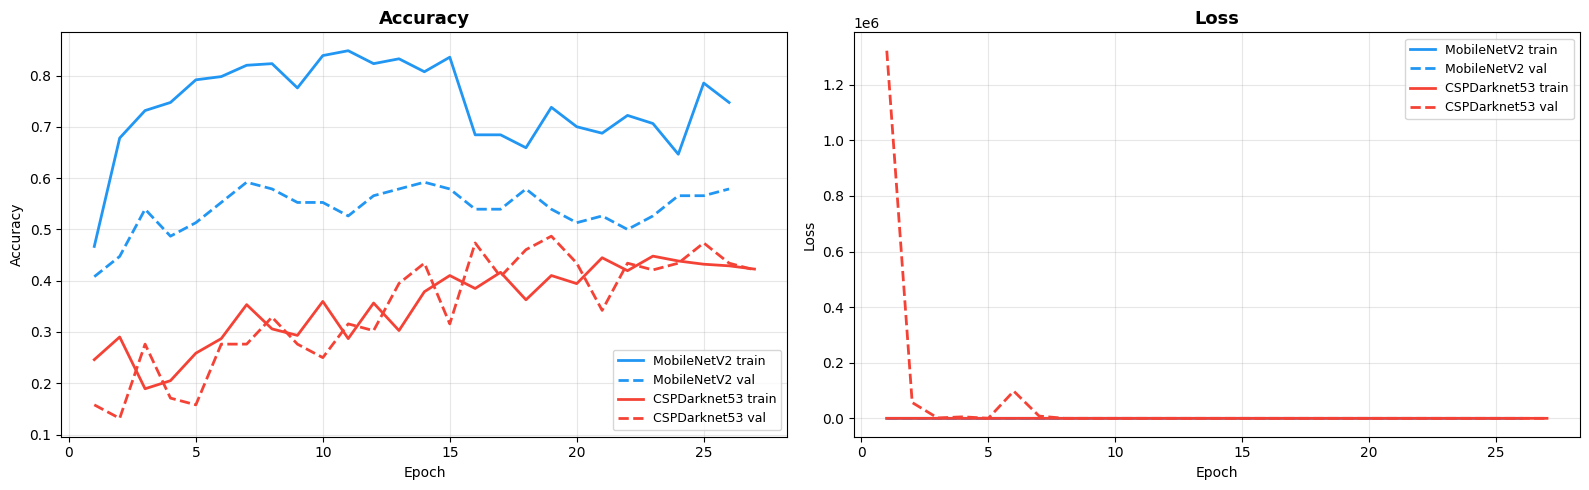

Plot disimpan: training_history.png


In [13]:
def merge_histories(*histories):
    """Gabung beberapa History objects jadi satu dict."""
    merged = {k: [] for k in histories[0].history.keys()}
    for h in histories:
        for k, v in h.history.items():
            merged[k].extend(v)
    return merged


def plot_training_history(histories_dict, model_names, figsize=(16, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

    for i, (hist, name) in enumerate(zip(histories_dict, model_names)):
        c = colors[i % len(colors)]
        epochs = range(1, len(hist['accuracy']) + 1)

        axes[0].plot(epochs, hist['accuracy'],     color=c, label=f'{name} train', linewidth=2)
        axes[0].plot(epochs, hist['val_accuracy'], color=c, label=f'{name} val',   linewidth=2, linestyle='--')
        axes[1].plot(epochs, hist['loss'],         color=c, label=f'{name} train', linewidth=2)
        axes[1].plot(epochs, hist['val_loss'],     color=c, label=f'{name} val',   linewidth=2, linestyle='--')

    for ax, title, ylabel in zip(axes, ['Accuracy', 'Loss'], ['Accuracy', 'Loss']):
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot disimpan: training_history.png")


# Gabungkan phase 1 + phase 2 untuk MobileNetV2
mn_history  = merge_histories(history_mn_head, history_mn_ft)
dn_history  = history_darknet.history

plot_training_history(
    [mn_history, dn_history],
    ['MobileNetV2', 'CSPDarknet53']
)

## 6. Evaluasi & Confusion Matrix


  MobileNetV2
  Validation Loss     : 2.2046
  Validation Accuracy : 0.5789 (57.89%)
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 449ms/step

              precision    recall  f1-score   support

    Asperata       0.50      0.33      0.40        12
      Dayana       0.58      0.55      0.56        20
   Pandurata       0.39      0.85      0.54        13
     Rumphii       0.88      0.71      0.79        21
    Swaniana       0.75      0.30      0.43        10

    accuracy                           0.58        76
   macro avg       0.62      0.55      0.54        76
weighted avg       0.64      0.58      0.58        76



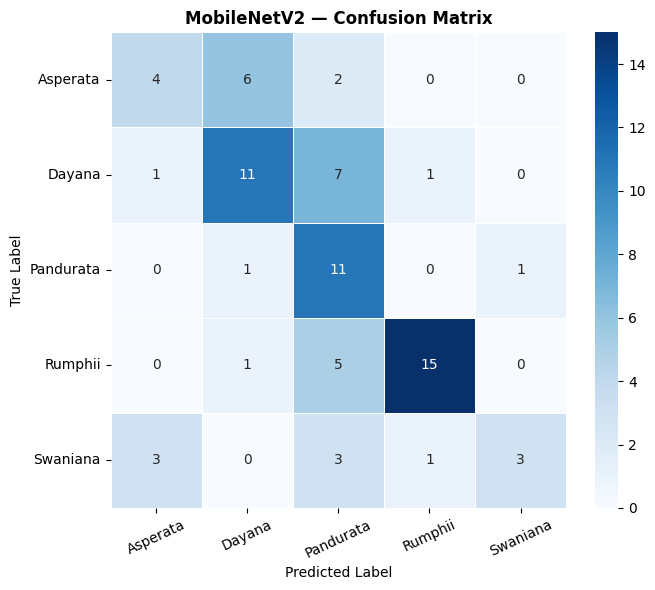

Confusion matrix disimpan: confusion_matrix_mobilenetv2.png

  CSPDarknet53
  Validation Loss     : 11.4424
  Validation Accuracy : 0.4868 (48.68%)
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 922ms/step

              precision    recall  f1-score   support

    Asperata       0.00      0.00      0.00        12
      Dayana       0.65      0.75      0.70        20
   Pandurata       0.00      0.00      0.00        13
     Rumphii       0.46      1.00      0.63        21
    Swaniana       0.33      0.10      0.15        10

    accuracy                           0.49        76
   macro avg       0.29      0.37      0.30        76
weighted avg       0.34      0.49      0.38        76



/Users/iganarendra/anggrek/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iganarendra/anggrek/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iganarendra/anggrek/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

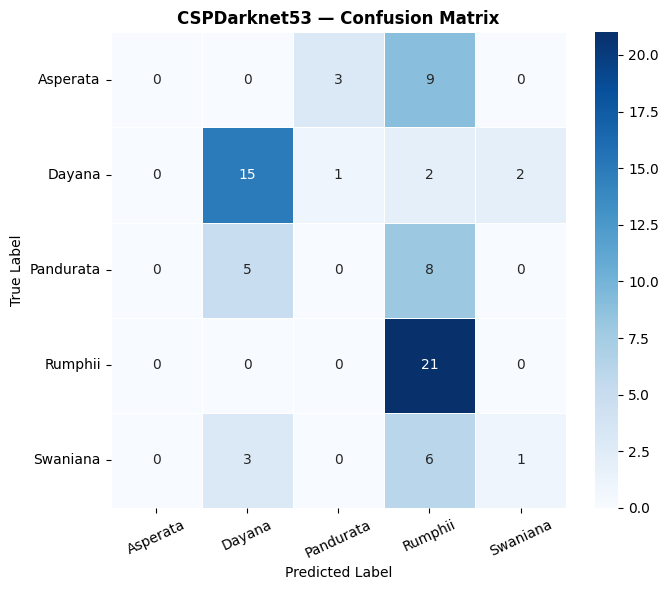

Confusion matrix disimpan: confusion_matrix_cspdarknet53.png


In [14]:
def evaluate_model(model, generator, class_names, model_name='Model'):
    generator.reset()
    
    # Loss & accuracy
    loss, acc = model.evaluate(generator, verbose=0)
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Validation Loss     : {loss:.4f}")
    print(f"  Validation Accuracy : {acc:.4f} ({acc*100:.2f}%)")

    # Prediksi
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes[:len(y_pred)]

    # Classification report
    print(f"\n{classification_report(y_true, y_pred, target_names=class_names)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5
    )
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=25)
    plt.yticks(rotation=0)
    plt.tight_layout()
    fname = f'confusion_matrix_{model_name.lower().replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix disimpan: {fname}")

    return loss, acc, y_true, y_pred


mn_loss, mn_acc, mn_true, mn_pred = evaluate_model(
    mobilenet_model, val_gen, CLASS_NAMES, 'MobileNetV2'
)
val_gen.reset()

dn_loss, dn_acc, dn_true, dn_pred = evaluate_model(
    darknet_model, val_gen, CLASS_NAMES, 'CSPDarknet53'
)
val_gen.reset()

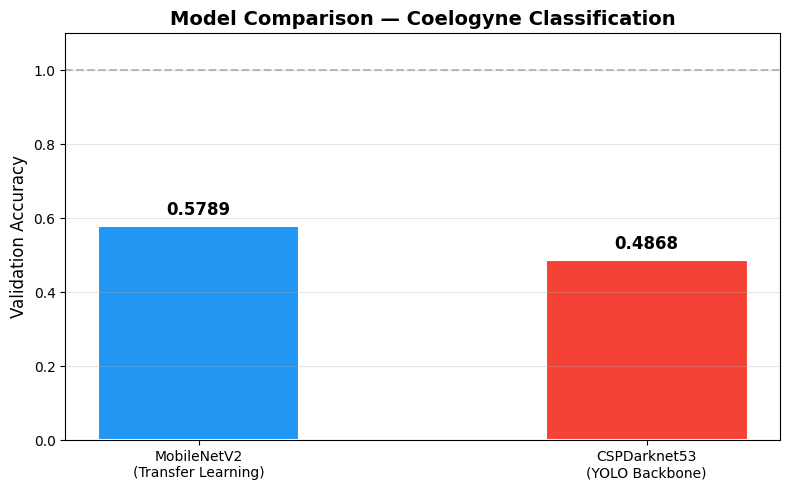

Perbandingan model disimpan: model_comparison.png


In [15]:
# ----------------------------------------------------------------
#  Perbandingan Model
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

models_info = {
    'MobileNetV2\n(Transfer Learning)': (mn_acc, '#2196F3'),
    'CSPDarknet53\n(YOLO Backbone)':    (dn_acc, '#F44336'),
}

bars = ax.bar(
    models_info.keys(),
    [v[0] for v in models_info.values()],
    color=[v[1] for v in models_info.values()],
    width=0.45, edgecolor='white', linewidth=1.5
)
ax.bar_label(bars, fmt='%.4f', padding=5, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Model Comparison — Coelogyne Classification', fontsize=14, fontweight='bold')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Perbandingan model disimpan: model_comparison.png")

## 7. Grad-CAM Visualization (Interpretability)

In [17]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)


ValueError: No such layer: Conv_1. Existing layers are: ['input_image', 'mobilenetv2_1.00_224', 'gap', 'bn_head', 'dropout_head', 'dense_256', 'dropout_2', 'predictions'].

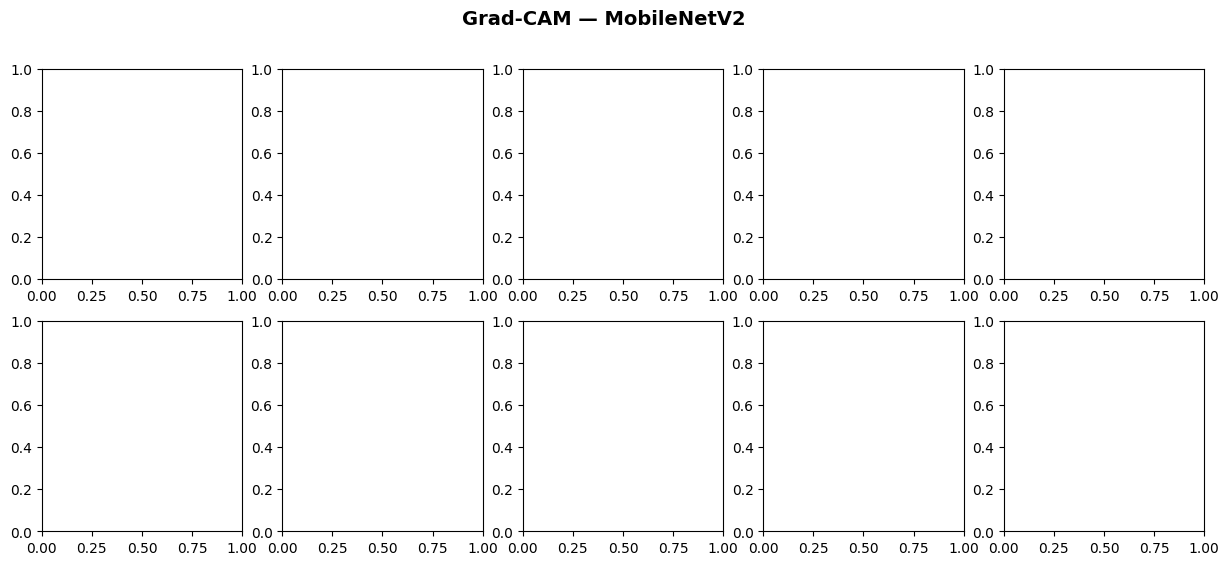

In [18]:
import cv2  # pip install opencv-python


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Grad-CAM heatmap."""
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    img_uint8 = np.uint8(img * 255)
    superimposed = cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)
    return superimposed


def show_gradcam_grid(model, generator, class_names, last_conv_name,
                      model_name='Model', n_samples=5):
    generator.reset()
    images, labels = next(generator)
    idx_to_class = {v: k for k, v in generator.class_indices.items()}

    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))
    fig.suptitle(f'Grad-CAM — {model_name}', fontsize=14, fontweight='bold')

    for i in range(n_samples):
        img = images[i]          # (H, W, 3) float
        true_label  = idx_to_class[np.argmax(labels[i])]
        img_input   = np.expand_dims(img, axis=0)  # (1, H, W, 3)
        preds       = model.predict(img_input, verbose=0)
        pred_label  = class_names[np.argmax(preds[0])]
        heatmap     = make_gradcam_heatmap(img_input, model, last_conv_name)
        overlay     = overlay_gradcam(img, heatmap)

        axes[0, i].imshow(img)
        axes[0, i].set_title(f'True: {true_label}', fontsize=8)
        axes[0, i].axis('off')

        correct = '✓' if pred_label == true_label else '✗'
        axes[1, i].imshow(overlay)
        axes[1, i].set_title(f'Pred: {pred_label} {correct}', fontsize=8,
                              color='green' if pred_label == true_label else 'red')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Original',   fontsize=10, rotation=90)
    axes[1, 0].set_ylabel('Grad-CAM',   fontsize=10, rotation=90)
    plt.tight_layout()
    fname = f'gradcam_{model_name.lower().replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Grad-CAM disimpan: {fname}")
    generator.reset()


# ---- MobileNetV2 Grad-CAM ----
# Last conv layer di MobileNetV2 adalah 'Conv_1'
show_gradcam_grid(
    mobilenet_model, val_gen, CLASS_NAMES,
    last_conv_name='Conv_1', model_name='MobileNetV2'
)

# ---- CSPDarknet53 Grad-CAM ----
# Last conv layer adalah 'stage5_transition_conv'
show_gradcam_grid(
    darknet_model, val_gen, CLASS_NAMES,
    last_conv_name='stage5_transition_conv', model_name='CSPDarknet53'
)

## 8. Inference — Prediksi Gambar Baru

In [19]:
from tensorflow.keras.preprocessing import image as keras_image


def predict_single_image(img_path, model, class_names, img_size=IMG_SIZE):
    """Predict spesies dari satu gambar."""
    img = keras_image.load_img(img_path, target_size=img_size)
    img_array = keras_image.img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    preds      = model.predict(img_input, verbose=0)[0]
    pred_idx   = np.argmax(preds)
    confidence = preds[pred_idx]

    # Plot
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))
    ax_img.imshow(img_array)
    ax_img.set_title(f'Prediction: {class_names[pred_idx]}\nConfidence: {confidence:.2%}',
                     fontweight='bold')
    ax_img.axis('off')

    colors = ['#4CAF50' if i == pred_idx else '#90CAF9' for i in range(len(class_names))]
    bars = ax_bar.barh(class_names, preds, color=colors)
    ax_bar.bar_label(bars, fmt='%.3f', padding=3)
    ax_bar.set_xlim(0, 1.15)
    ax_bar.set_xlabel('Probability')
    ax_bar.set_title(f'Class Probabilities ({model.name})')
    ax_bar.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return class_names[pred_idx], confidence, preds


# Contoh penggunaan:
# pred_class, conf, probs = predict_single_image(
#     'path/to/your/image.jpg',
#     mobilenet_model,  # atau darknet_model
#     CLASS_NAMES
# )
# print(f"Predicted: {pred_class} ({conf:.2%})")

print("Fungsi predict_single_image siap digunakan.")
print("Contoh: predict_single_image('gambar_anggrek.jpg', mobilenet_model, CLASS_NAMES)")

Fungsi predict_single_image siap digunakan.
Contoh: predict_single_image('gambar_anggrek.jpg', mobilenet_model, CLASS_NAMES)


## 9. Simpan Model

In [20]:
# Simpan dalam format Keras (.keras) dan TFLite untuk deployment

# ---- SavedModel / .keras ----
mobilenet_path = os.path.join(SAVE_DIR, 'mobilenetv2_coelogyne_final.keras')
darknet_path   = os.path.join(SAVE_DIR, 'cspdarknet53_coelogyne_final.keras')

mobilenet_model.save(mobilenet_path)
darknet_model.save(darknet_path)
print(f"MobileNetV2 disimpan : {mobilenet_path}")
print(f"CSPDarknet53 disimpan: {darknet_path}")

# ---- TFLite (opsional, untuk mobile deployment) ----
def export_tflite(model, output_path, quantize=False):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    if quantize:
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    with open(output_path, 'wb') as f:
        f.write(tflite_model)
    size_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f"TFLite saved: {output_path} ({size_mb:.2f} MB)")

export_tflite(mobilenet_model, os.path.join(SAVE_DIR, 'mobilenetv2_coelogyne.tflite'))
export_tflite(darknet_model,   os.path.join(SAVE_DIR, 'cspdarknet53_coelogyne.tflite'))

# Quantized (lebih kecil untuk mobile)
export_tflite(mobilenet_model, os.path.join(SAVE_DIR, 'mobilenetv2_coelogyne_quant.tflite'), quantize=True)

MobileNetV2 disimpan : ./saved_models/mobilenetv2_coelogyne_final.keras
CSPDarknet53 disimpan: ./saved_models/cspdarknet53_coelogyne_final.keras
INFO:tensorflow:Assets written to: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmptxiwi4nt/assets


INFO:tensorflow:Assets written to: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmptxiwi4nt/assets


Saved artifact at '/var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmptxiwi4nt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  12984743888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984745040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984745424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984744656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984742352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984745232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984744464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984744272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984744848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984743696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984744080

W0000 00:00:1777980826.042886  846522 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777980826.044767  846522 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-05-05 18:33:46.052619: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmptxiwi4nt
2026-05-05 18:33:46.057764: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-05-05 18:33:46.057776: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmptxiwi4nt
I0000 00:00:1777980826.117554  846522 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2026-05-05 18:33:46.130290: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-05-05 18:33:46.528675: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folder

TFLite saved: ./saved_models/mobilenetv2_coelogyne.tflite (9.71 MB)
INFO:tensorflow:Assets written to: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmpwlrpj4n2/assets


...

W0000 00:00:1777980832.551558  846522 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777980832.551580  846522 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-05-05 18:33:52.551767: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmpwlrpj4n2
2026-05-05 18:33:52.558857: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-05-05 18:33:52.558870: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmpwlrpj4n2
2026-05-05 18:33:52.657152: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-05-05 18:33:53.264401: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmpwlrpj4n2
2026-05-05 18:33:53.422692: I tensorflow/cc/saved_model/loader.cc:

TFLite saved: ./saved_models/cspdarknet53_coelogyne.tflite (103.51 MB)
INFO:tensorflow:Assets written to: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmpna5py9wq/assets


INFO:tensorflow:Assets written to: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmpna5py9wq/assets


Saved artifact at '/var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmpna5py9wq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  12984743888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984745040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984745424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984744656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984742352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984745232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984744464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984744272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984744848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984743696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12984744080

W0000 00:00:1777980838.849399  846522 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777980838.849411  846522 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-05-05 18:33:58.849572: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmpna5py9wq
2026-05-05 18:33:58.854463: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-05-05 18:33:58.854474: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmpna5py9wq
2026-05-05 18:33:58.929506: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-05-05 18:33:59.323460: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/tmpna5py9wq
2026-05-05 18:33:59.433934: I tensorflow/cc/saved_model/loader.cc:

## 10. Ringkasan Hasil


In [21]:
import datetime

print('=' * 65)
print(f'  RINGKASAN HASIL — Coelogyne Classification')
print(f'  {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}')
print('=' * 65)
print(f'  Dataset     : 5 spesies Coelogyne')
print(f'  Image size  : {IMG_SIZE}')
print(f'  Batch size  : {BATCH_SIZE}')
print()
print(f'  MODEL 1 — MobileNetV2 (ImageNet pretrained)')
print(f'    Params      : {mobilenet_model.count_params():,}')
print(f'    Val Accuracy: {mn_acc:.4f} ({mn_acc*100:.2f}%)')
print(f'    Val Loss    : {mn_loss:.4f}')
print()
print(f'  MODEL 2 — CSPDarknet53 (YOLO Backbone, from scratch)')
print(f'    Params      : {darknet_model.count_params():,}')
print(f'    Val Accuracy: {dn_acc:.4f} ({dn_acc*100:.2f}%)')
print(f'    Val Loss    : {dn_loss:.4f}')
print()
winner = 'MobileNetV2' if mn_acc > dn_acc else 'CSPDarknet53'
print(f'  ✅ Model terbaik: {winner}')
print('=' * 65)

  RINGKASAN HASIL — Coelogyne Classification
  2026-05-05 18:33
  Dataset     : 5 spesies Coelogyne
  Image size  : (224, 224)
  Batch size  : 8

  MODEL 1 — MobileNetV2 (ImageNet pretrained)
    Params      : 2,592,325
    Val Accuracy: 0.5789 (57.89%)
    Val Loss    : 2.2046

  MODEL 2 — CSPDarknet53 (YOLO Backbone, from scratch)
    Params      : 27,161,957
    Val Accuracy: 0.4868 (48.68%)
    Val Loss    : 11.4424

  ✅ Model terbaik: MobileNetV2
